In [1]:
from google.colab import files
uploaded = files.upload()

Saving historical_automobile_sales.csv to historical_automobile_sales.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('historical_automobile_sales.csv')
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


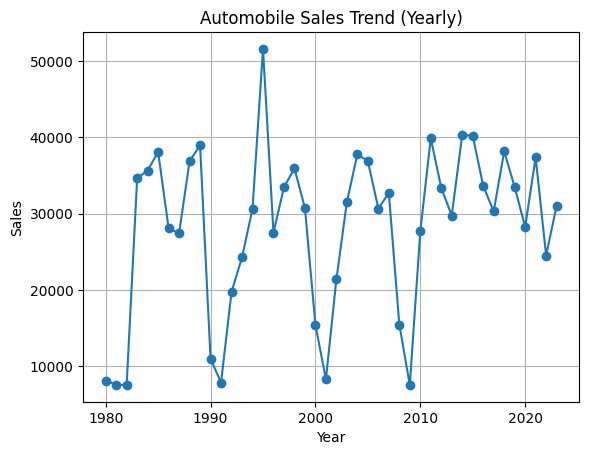

In [5]:
## Q 1: Develop a Line chart using the functionality of pandas to show how automobile sales fluctuate from year to year.

yearly_sales = df.groupby('Year')['Automobile_Sales'].sum()

yearly_sales.plot(kind='line', marker='o')
plt.title('Automobile Sales Trend (Yearly)')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.grid()

plt.show()

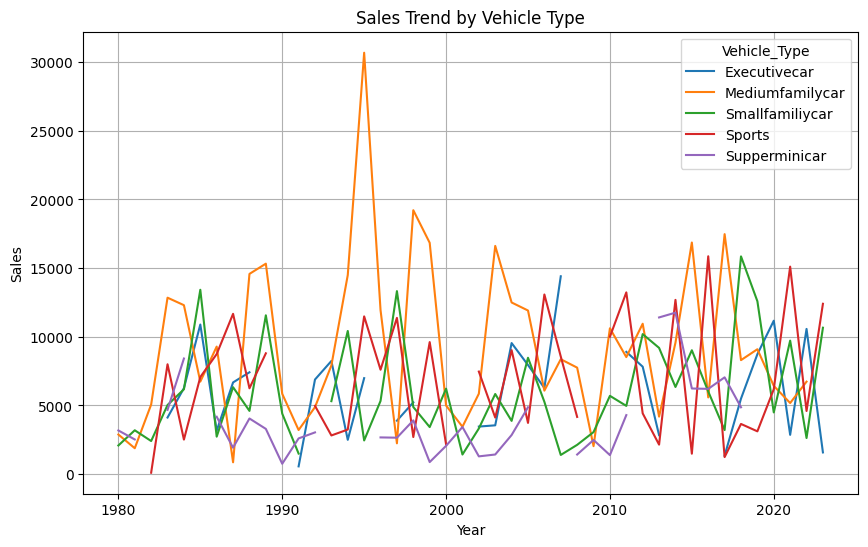

In [6]:
## Q 2: Plot different lines for categories of vehicle type and analyze
## the trend to answer the question Is there a noticeable difference in
## sales trends between different vehicle types during recession periods?


vehicle_trend = df.groupby(['Year', 'Vehicle_Type'])['Automobile_Sales'].sum().unstack()

vehicle_trend.plot(figsize=(10,6))
plt.title('Sales Trend by Vehicle Type')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.grid()

plt.show()






During recession periods, automobile sales show a noticeable decline.
Luxury and sports vehicles are more affected, while smaller and economical vehicles show relatively stable trends.
This indicates that consumers prefer budget-friendly vehicles during economic downturns.

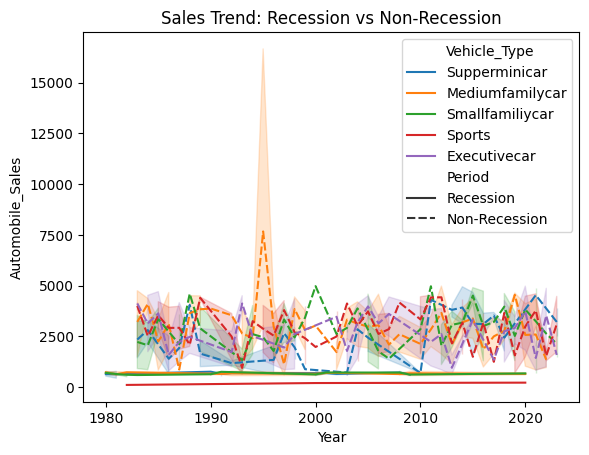

In [8]:
## Q 3: Use the functionality of Seaborn Library to create a visualization to compare the sales trend per vehicle type for a recession period with a non- recession
## period.

df['Period'] = df['Recession'].map({0: 'Non-Recession', 1: 'Recession'})

sns.lineplot(data=df, x='Year', y='Automobile_Sales', hue='Vehicle_Type', style='Period')

plt.title('Sales Trend: Recession vs Non-Recession')
plt.show()

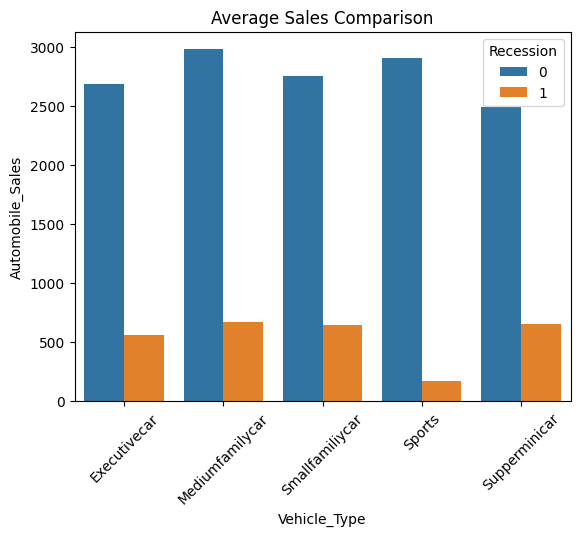

In [9]:
## Q 4: Now you want to compare the sales of different vehicle types during a recession and a non-recession period

avg_sales = df.groupby(['Vehicle_Type', 'Recession'])['Automobile_Sales'].mean().reset_index()

sns.barplot(data=avg_sales, x='Vehicle_Type', y='Automobile_Sales', hue='Recession')

plt.title('Average Sales Comparison')
plt.xticks(rotation=45)

plt.show()